In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [ ]:
folders = [
    'data/raw',
    'data/processed',
    'models',
    'notebooks',
    'src',
    'app',
    'reports/eda'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'Created: {folder}')

print('\nFolder structure ready!')

In [2]:
df_raw = pd.read_csv('C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\raw\\Loan_new.csv')
df_raw.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  str    
 5   EducationLevel              20000 non-null  str    
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  str    
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  str    
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   20000 non-null

In [4]:
df_raw.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [5]:
print('=== SHAPE ===')
print(f'Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}')

print('\n=== COLUMN NAMES ===')
print(list(df_raw.columns))

print('\n=== FIRST 5 ROWS ===')
df_raw.head()

=== SHAPE ===
Rows: 20000, Columns: 36

=== COLUMN NAMES ===
['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

=== FIRST 5 ROWS ===


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [6]:
print('=== DATA TYPES ===')
print(df_raw.dtypes)

print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print('No missing values found. Dataset is clean.')
else:
    print('Missing values detected:')
    print(missing[missing > 0])

=== DATA TYPES ===
ApplicationDate                   str
Age                             int64
AnnualIncome                    int64
CreditScore                     int64
EmploymentStatus                  str
EducationLevel                    str
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                     str
NumberOfDependents              int64
HomeOwnershipStatus               str
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory               int64
LoanPurpose                       str
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance           int64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities               

In [7]:
print('=== STATISTICAL SUMMARY ===')
display(df_raw.describe().round(2))

print('\n=== CATEGORICAL COLUMNS & UNIQUE VALUES ===')
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')
for col in cat_cols:
    print(f'\n  {col}: {df_raw[col].unique()}')

=== STATISTICAL SUMMARY ===


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,...,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,39.75,59161.47,571.61,17.52,24882.87,54.06,1.52,454.29,0.29,3.02,...,4891.72,0.80,5.00,72294.32,0.24,0.24,911.61,0.40,0.24,50.77
std,11.62,40350.85,51.00,11.32,13427.42,24.66,1.39,240.51,0.16,1.74,...,3296.77,0.12,2.24,117920.02,0.04,0.04,674.58,0.34,0.43,7.78
min,18.00,15000.00,343.00,0.00,3674.00,12.00,0.00,50.00,0.00,0.00,...,1250.00,0.26,0.00,1000.00,0.13,0.11,97.03,0.02,0.00,28.80
25%,32.00,31679.00,540.00,9.00,15575.00,36.00,0.00,286.00,0.16,2.00,...,2629.58,0.73,3.00,8734.75,0.21,0.21,493.76,0.18,0.00,46.00
50%,40.00,48566.00,578.00,17.00,21914.50,48.00,1.00,402.00,0.27,3.00,...,4034.75,0.82,5.00,32855.50,0.24,0.24,728.51,0.30,0.00,52.00
75%,48.00,74391.00,609.00,25.00,30835.00,72.00,2.00,564.00,0.39,4.00,...,6163.00,0.89,6.00,88825.50,0.26,0.27,1112.77,0.51,0.00,56.00
max,80.00,485341.00,712.00,61.00,184732.00,120.00,5.00,2919.00,0.92,13.00,...,25000.00,1.00,16.00,2603208.00,0.41,0.45,10892.63,4.65,1.00,84.00



=== CATEGORICAL COLUMNS & UNIQUE VALUES ===
Categorical columns: ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

  ApplicationDate: <StringArray>
['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
 '2018-01-06', '2018-01-07', '2018-01-08', '2018-01-09', '2018-01-10',
 ...
 '2072-09-24', '2072-09-25', '2072-09-26', '2072-09-27', '2072-09-28',
 '2072-09-29', '2072-09-30', '2072-10-01', '2072-10-02', '2072-10-03']
Length: 20000, dtype: str

  EmploymentStatus: <StringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str

  EducationLevel: <StringArray>
['Master', 'Associate', 'Bachelor', 'High School', 'Doctorate']
Length: 5, dtype: str

  MaritalStatus: <StringArray>
['Married', 'Single', 'Divorced', 'Widowed']
Length: 4, dtype: str

  HomeOwnershipStatus: <StringArray>
['Own', 'Mortgage', 'Rent', 'Other']
Length: 4, dtype: str

  LoanPurpose: <StringArray>
['Home', 'Debt Consolidati

C:\Users\hp\AppData\Local\Temp\ipykernel_26184\2412338495.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_raw.select_dtypes(include='object').columns.tolist()


In [8]:
print('=== TARGET: LoanApproved (1=Approved, 0=Rejected) ===')
vc = df_raw['LoanApproved'].value_counts()
print(vc)

pct_approved = vc[1] / len(df_raw) * 100
pct_rejected = vc[0] / len(df_raw) * 100
print(f'\nApproved: {pct_approved:.1f}%')
print(f'Rejected: {pct_rejected:.1f}%')

if abs(pct_approved - 50) > 15:
    print('\nClass imbalance detected!')
    print('  Tell Person 2 to use scale_pos_weight in XGBoost or SMOTE.')
else:
    print('\nClasses are reasonably balanced.')

=== TARGET: LoanApproved (1=Approved, 0=Rejected) ===
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Approved: 23.9%
Rejected: 76.1%

Class imbalance detected!
  Tell Person 2 to use scale_pos_weight in XGBoost or SMOTE.


In [9]:
df = df_raw.copy()

cols_to_drop = []

if 'RiskScore' in df.columns:
    cols_to_drop.append('RiskScore')
    print('Will drop: RiskScore (TARGET LEAKAGE)')

df.drop(columns=cols_to_drop, inplace=True)
print(f'\nShape after dropping: {df.shape}')

Will drop: RiskScore (TARGET LEAKAGE)

Shape after dropping: (20000, 35)


In [10]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Removed {dup_count} duplicates. New shape: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows found: 0
No duplicates found.


In [11]:
print(f'Age min: {df["Age"].min()}, Age max: {df["Age"].max()}')

# Drop only impossible/corrupt age values, not legitimate older/younger applicants
impossible_age = df[(df['Age'] < 18) | (df['Age'] > 100)]
if len(impossible_age) > 0:
    print(f'{len(impossible_age)} rows with impossible age values — removing them')
    df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
    print(f'New shape: {df.shape}')
else:
    print('No impossible age values found.')

print(f'\nAge distribution:')
print(df['Age'].describe().round(1))

Age min: 18, Age max: 80
No impossible age values found.

Age distribution:
count    20000.0
mean        39.8
std         11.6
min         18.0
25%         32.0
50%         40.0
75%         48.0
max         80.0
Name: Age, dtype: float64


In [12]:
numeric_candidates = [
    'AnnualIncome', 'MonthlyIncome', 'LoanAmount', 'LoanDuration',
    'CreditScore', 'CreditCardUtilizationRate', 'NumberOfCreditLines',
    'NumberOfOpenCreditLines', 'DebtToIncomeRatio', 'NumberOfDependents',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
    'TotalLiabilities', 'MonthlyExpenses', 'UtilityBills', 'JobTenure',
    'NetWorth', 'BaselineInterestRate', 'MonthlyDebt', 'TotalDebt',
    'Experience', 'PaymentHistory', 'LengthOfCreditHistory'
]

converted = []
for col in numeric_candidates:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
        converted.append(col)

if converted:
    print(f'Converted to numeric: {converted}')
else:
    print('All numeric columns already have correct dtypes.')

All numeric columns already have correct dtypes.


In [ ]:
df.to_csv('data/processed/loan_cleaned.csv', index=False)
print(f'Saved: data/processed/loan_cleaned.csv')
print(f'Shape: {df.shape}')

In [14]:
# 1. Missed payment flag
df['MissedPaymentFlag'] = (df['PreviousLoanDefaults'] > 0).astype(int)

# 2. High utilization flag
#    Uses CreditCardUtilizationRate — verify this matches your dataset column name
utilization_col = 'CreditCardUtilizationRate' if 'CreditCardUtilizationRate' in df.columns else 'CreditCardUtilization'
df['HighUtilizationFlag'] = (df[utilization_col] > 0.75).astype(int)

# 3. Savings to loan ratio
df['SavingsToLoanRatio'] = (
    df['SavingsAccountBalance'] / (df['LoanAmount'] + 1e-5)
).round(4)

# 4. EMI burden ratio — monthly debt obligations as fraction of monthly income
#    Central to cohort intelligence: "applicants who defaulted had EMI burden > 45%"
if 'MonthlyDebtPayments' in df.columns and 'MonthlyIncome' in df.columns:
    df['EMIBurdenRatio'] = (df['MonthlyDebtPayments'] / (df['MonthlyIncome'] + 1e-5)).round(4)
    print('EMIBurdenRatio engineered.')

# 5. Age group — for fairness analysis only, not a model feature
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 30, 45, 64, 100],
    labels=['Young (18-30)', 'Mid (31-45)', 'Senior (46-64)', 'Elder (65+)']
)

print('Feature engineering complete!')
print(df[['MissedPaymentFlag', 'HighUtilizationFlag',
          'SavingsToLoanRatio', 'EMIBurdenRatio', 'AgeGroup']].head())

EMIBurdenRatio engineered.
Feature engineering complete!
   MissedPaymentFlag  HighUtilizationFlag  SavingsToLoanRatio  EMIBurdenRatio  \
0                  0                    0              0.5803          0.0550   
1                  0                    0              0.1777          0.1499   
2                  0                    0              0.0503          0.2658   
3                  0                    0              0.0442          0.1311   
4                  0                    0              0.1693          0.0318   

         AgeGroup  
0     Mid (31-45)  
1     Mid (31-45)  
2  Senior (46-64)  
3  Senior (46-64)  
4     Mid (31-45)  


In [16]:
df_pre_encode = df.copy()
print('Pre-encoding copy saved as df_pre_encode')
print(f'Shape: {df_pre_encode.shape}')

Pre-encoding copy saved as df_pre_encode
Shape: (20000, 39)


In [ ]:
df_pre_encode.to_csv('data/processed/loan_pre_encode.csv', index=False)
print(f'Saved: data/processed/loan_pre_encode.csv')
print(f'Shape: {df_pre_encode.shape}')

In [17]:
if 'ApplicationDate' in df.columns:
    df.drop(columns=['ApplicationDate'], inplace=True)
    df_pre_encode.drop(columns=['ApplicationDate'], inplace=True)
    print('Dropped: ApplicationDate')

remaining_cat = df.select_dtypes(include='object').columns.tolist()
remaining_cat = [c for c in remaining_cat if c != 'AgeGroup']

print(f'\nColumns being one-hot encoded: {remaining_cat}')

df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)

print(f'\nOne-hot encoding done.')
print(f'New shape: {df.shape}')
print(f'\nAll columns after encoding:')
print(list(df.columns))


Columns being one-hot encoded: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

One-hot encoding done.
New shape: (20000, 50)

All columns after encoding:
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'MissedPaymentFlag', 'HighUtilizationFlag', 'SavingsToLoanRatio', 'AgeGroup', 'EMIBurdenRatio', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 'Edu

C:\Users\hp\AppData\Local\Temp\ipykernel_26184\1584835376.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df.select_dtypes(include='object').columns.tolist()


In [18]:
PROTECTED_ATTRS = ['Age', 'AgeGroup', 'MaritalStatus']
PROTECTED_ATTRS = [a for a in PROTECTED_ATTRS if a in df_pre_encode.columns]

with open('protected_attrs.txt', 'w') as f:
    for attr in PROTECTED_ATTRS:
        f.write(attr + '\n')

print(f'Saved: protected_attrs.txt')
print(f'Protected attributes: {PROTECTED_ATTRS}')

Saved: protected_attrs.txt
Protected attributes: ['Age', 'AgeGroup', 'MaritalStatus']


In [19]:
cols_to_exclude = ['AgeGroup', 'ApplicationID', 'EMIBurdenRatio']
cols_to_exclude = [c for c in cols_to_exclude if c in df.columns]

df_for_model = df.drop(columns=cols_to_exclude)

X = df_for_model.drop(columns=['LoanApproved'])
y = df_for_model['LoanApproved']

print(f'Features X: {X.shape}')
print(f'Target y:   {y.shape}')
print(f'\nAll feature columns ({len(X.columns)} total):')
print(list(X.columns))

Features X: (20000, 47)
Target y:   (20000,)

All feature columns (47 total):
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'MissedPaymentFlag', 'HighUtilizationFlag', 'SavingsToLoanRatio', 'EmploymentStatus_Self-Employed', 'EmploymentStatus_Unemployed', 'EducationLevel_Bachelor', 'EducationLevel_Doctorate', 'EducationLevel_High School', 'EducationLevel_Master', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'HomeOwnershipStatus_Other', 'HomeOwnershipSt

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Training rows:  {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test rows:      {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nTrain class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

Training rows:  16000 (80.0%)
Test rows:      4000 (20.0%)

Train class balance: {0: 12176, 1: 3824}
Test class balance:  {0: 3044, 1: 956}


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print('Scaling complete!')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')

Scaling complete!
X_train_scaled: (16000, 47)
X_test_scaled:  (4000, 47)


In [ ]:
sensitive_cols = [a for a in PROTECTED_ATTRS if a in df_pre_encode.columns]

sensitive_train = df_pre_encode.loc[X_train.index, sensitive_cols]
sensitive_test  = df_pre_encode.loc[X_test.index,  sensitive_cols]

sensitive_train.to_csv('data/processed/sensitive_train.csv', index=False)
sensitive_test.to_csv('data/processed/sensitive_test.csv',   index=False)

print('Sensitive feature files saved:')
print('  data/processed/sensitive_train.csv')
print('  data/processed/sensitive_test.csv')
print(f'  Columns saved: {sensitive_cols}')

In [ ]:
X_train_scaled.to_csv('data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test.csv',   index=False)
y_train.to_csv('data/processed/y_train.csv',         index=False)
y_test.to_csv('data/processed/y_test.csv',           index=False)

joblib.dump(scaler, 'models/scaler.pkl')

print('All files saved:')
print('  data/processed/X_train.csv')
print('  data/processed/X_test.csv')
print('  data/processed/y_train.csv')
print('  data/processed/y_test.csv')
print('  models/scaler.pkl')

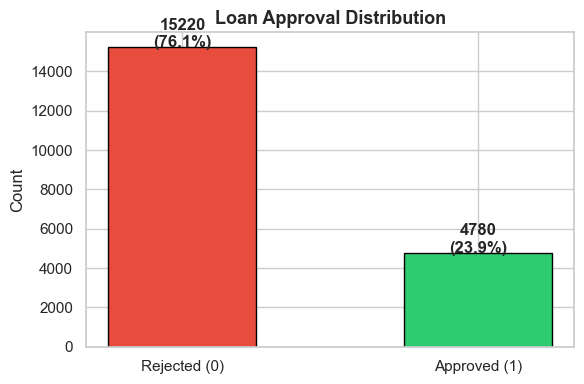

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_pre_encode['LoanApproved'].value_counts().sort_index()  # sort by 0, 1
colors = ['#e74c3c', '#2ecc71']  # index 0 = Rejected = red, index 1 = Approved = green
ax.bar(['Rejected (0)', 'Approved (1)'], counts.values,
       color=colors, edgecolor='black', width=0.5)
ax.set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v}\n({v/len(df_pre_encode)*100:.1f}%)',
            ha='center', fontweight='bold')
plt.tight_layout()
# plt.savefig('reports/eda/class_distribution.png', bbox_inches='tight')
plt.show()

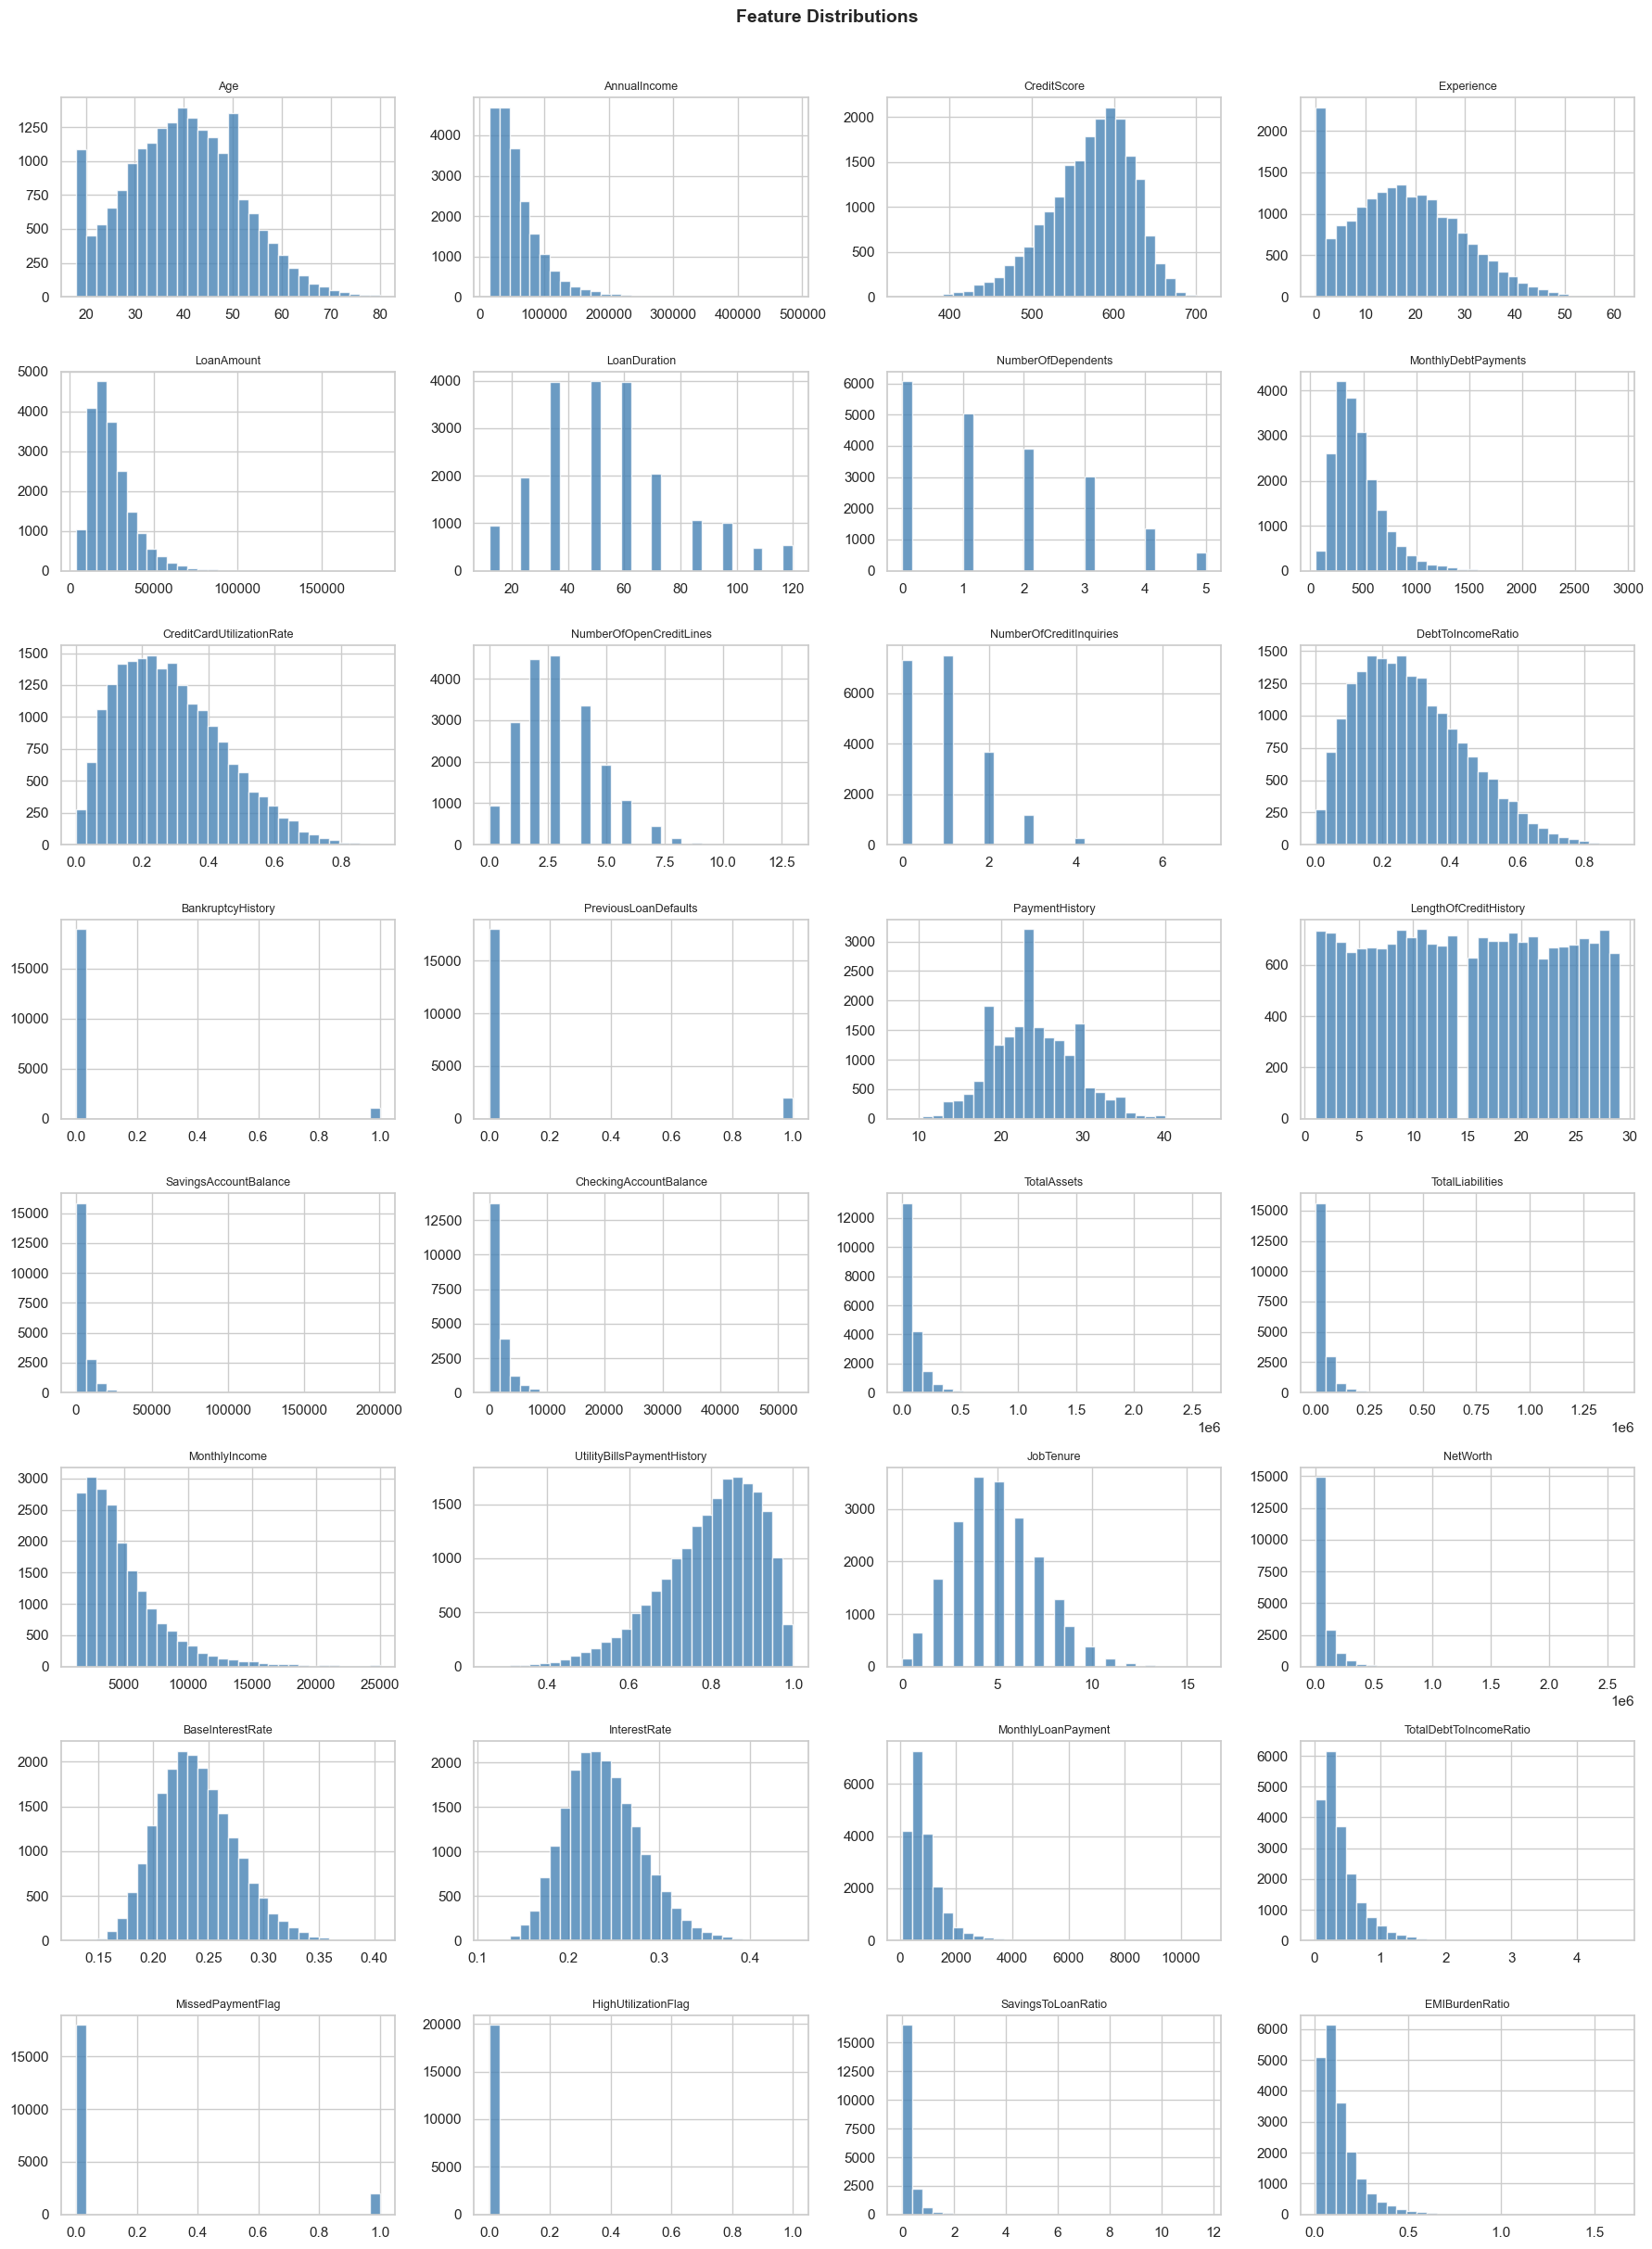

In [24]:
num_cols = df_pre_encode.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'LoanApproved']

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_pre_encode[col], bins=30,
                 color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('reports/eda/feature_distributions.png', bbox_inches='tight')
plt.show()

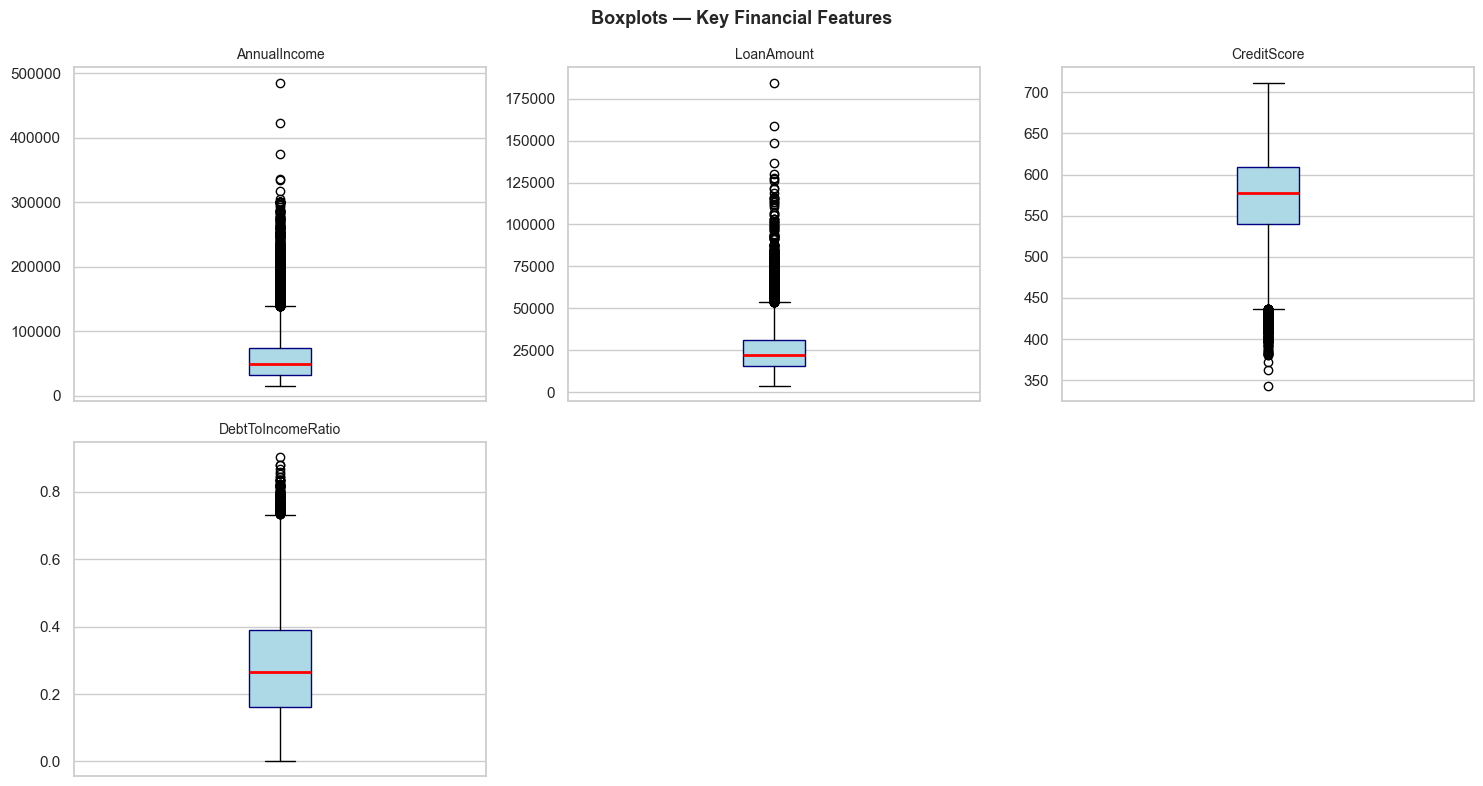

In [25]:
boxplot_cols = ['AnnualIncome', 'LoanAmount', 'CreditScore',
                'DebtToIncomeRatio', 'MonthlyExpenses', 'TotalDebt']
boxplot_cols = [c for c in boxplot_cols if c in df_pre_encode.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols):
    axes[i].boxplot(df_pre_encode[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Key Financial Features', fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('reports/eda/boxplots_key_features.png', bbox_inches='tight')
plt.show()

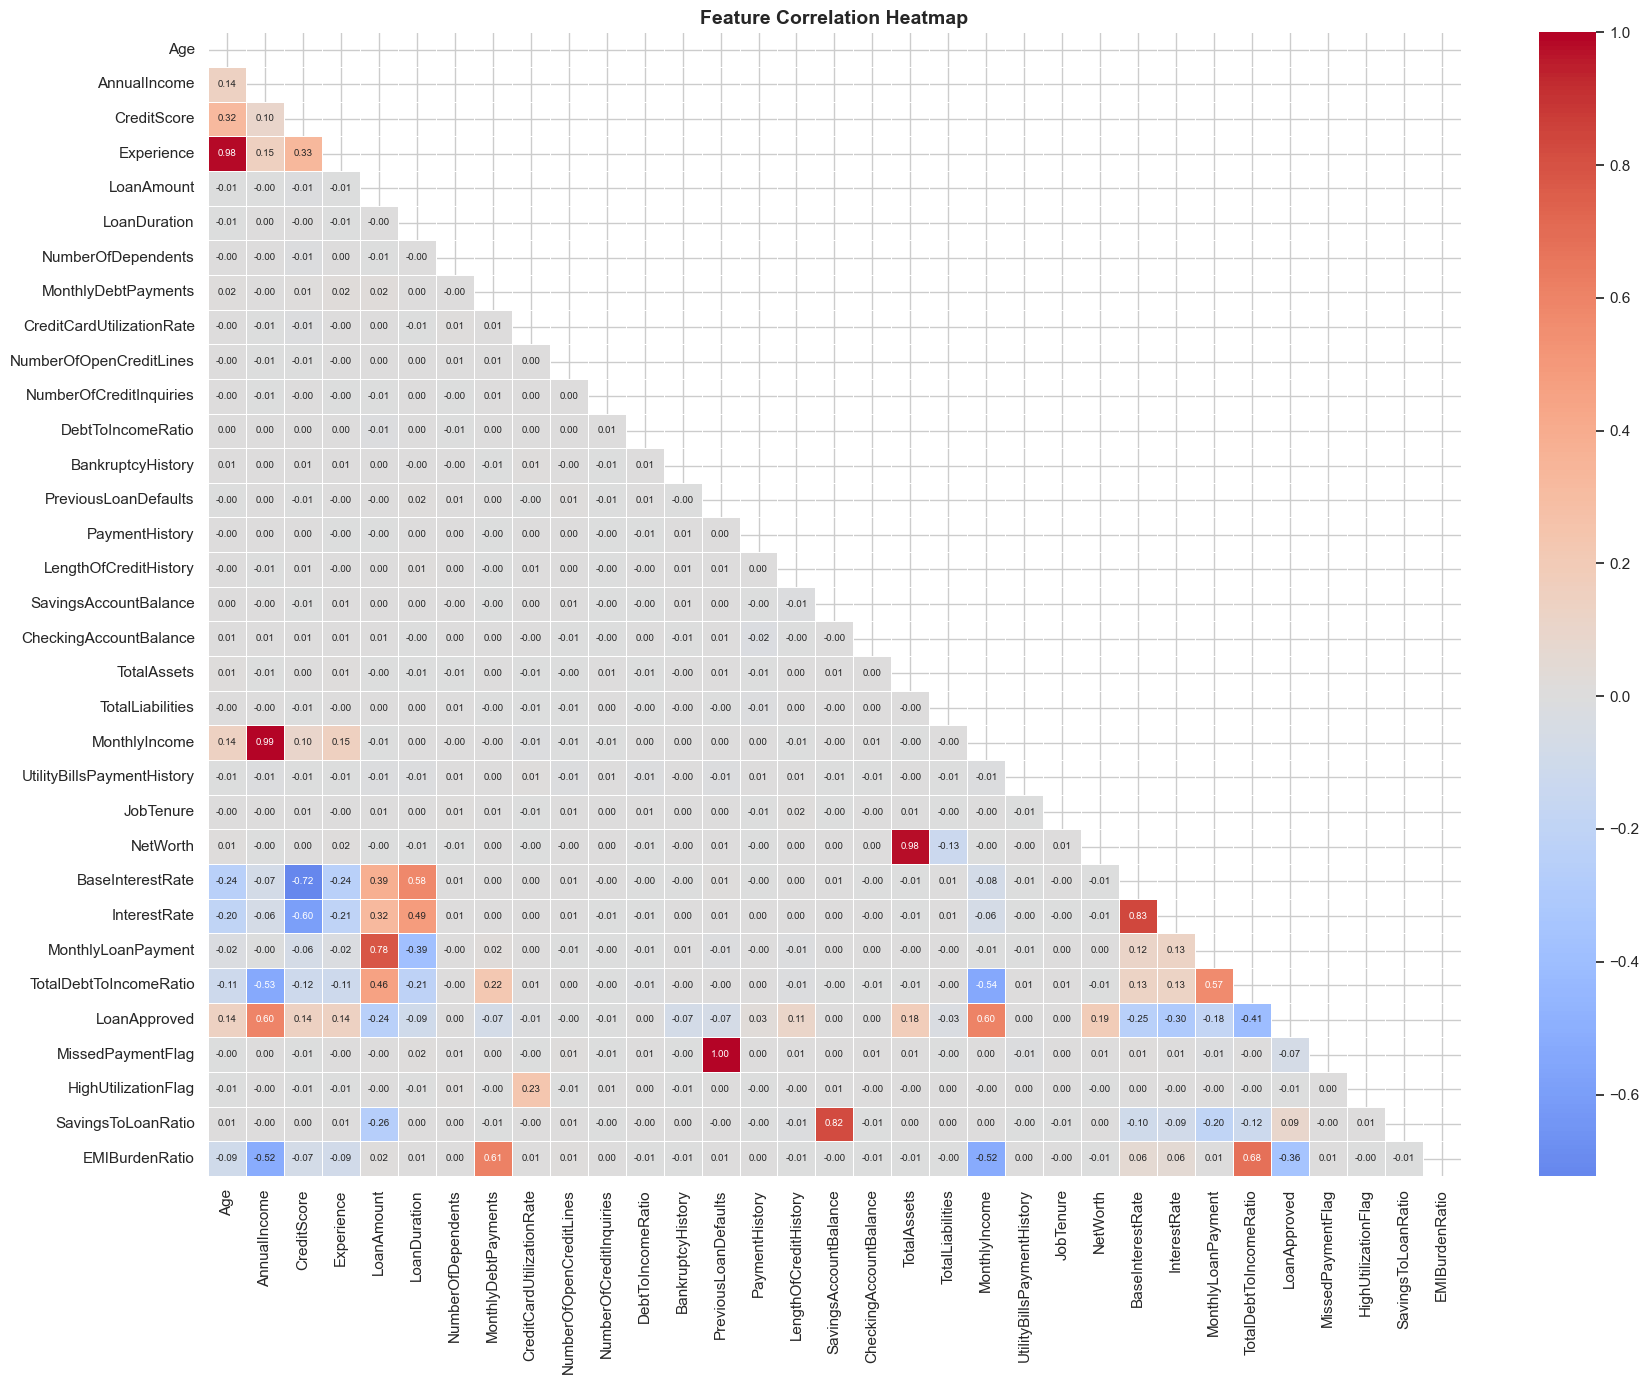


=== TOP 10 CORRELATIONS WITH LoanApproved ===
MonthlyIncome             0.604101
AnnualIncome              0.597900
TotalDebtToIncomeRatio    0.410399
EMIBurdenRatio            0.355323
InterestRate              0.301646
BaseInterestRate          0.247263
LoanAmount                0.239496
NetWorth                  0.187892
MonthlyLoanPayment        0.184272
TotalAssets               0.184011
Name: LoanApproved, dtype: float64


In [26]:
numeric_df = df_pre_encode.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.4)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('reports/eda/correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n=== TOP 10 CORRELATIONS WITH LoanApproved ===')
print(corr['LoanApproved'].drop('LoanApproved').abs()
      .sort_values(ascending=False).head(10))

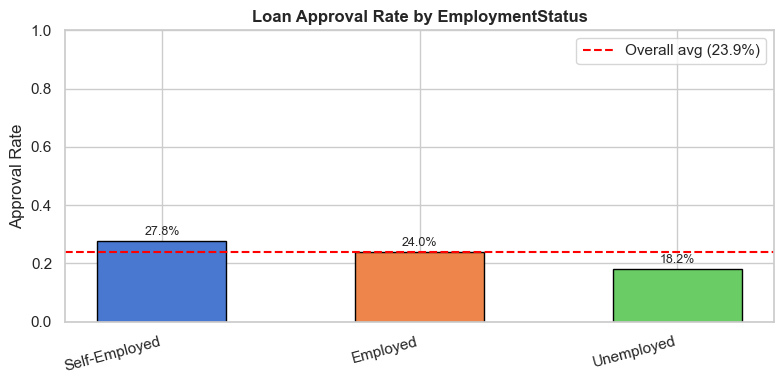

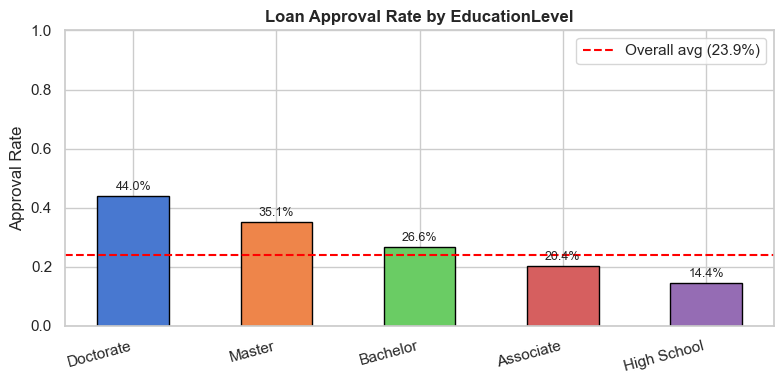

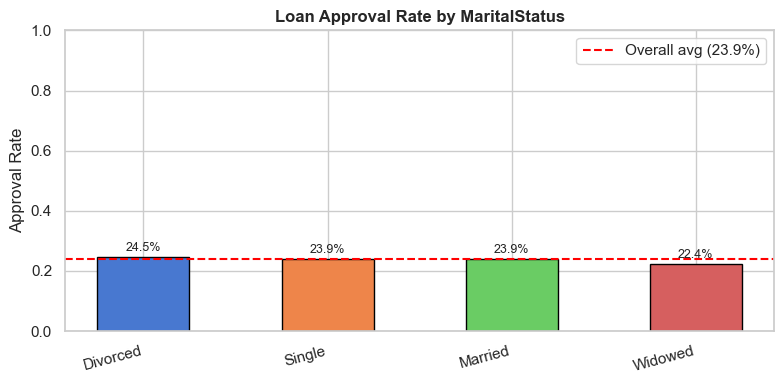

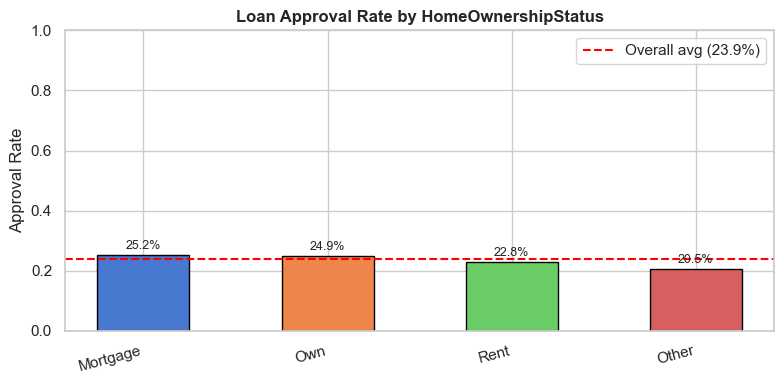

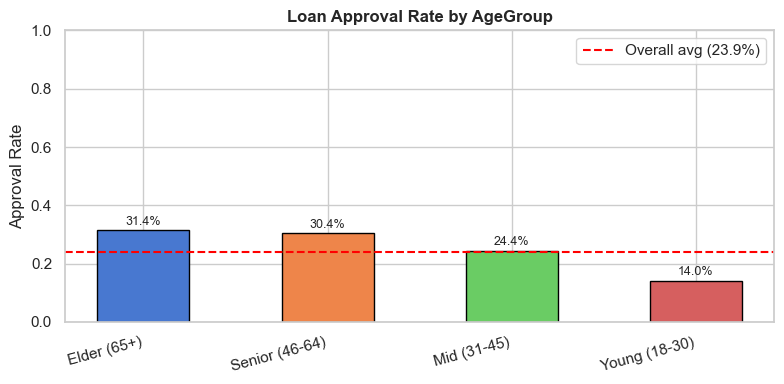

In [27]:
fairness_check_cols = [
    'EmploymentStatus', 'EducationLevel', 'MaritalStatus',
    'HomeOwnershipStatus', 'AgeGroup'
]
fairness_check_cols = [c for c in fairness_check_cols if c in df_pre_encode.columns]

for col in fairness_check_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    group_rate = (df_pre_encode.groupby(col)['LoanApproved']
                  .mean().sort_values(ascending=False))
    bars = ax.bar(group_rate.index.astype(str), group_rate.values,
                  color=sns.color_palette('muted', len(group_rate)),
                  edgecolor='black', width=0.5)
    ax.set_title(f'Loan Approval Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Approval Rate')
    ax.set_ylim(0, 1)
    overall_avg = df_pre_encode['LoanApproved'].mean()
    ax.axhline(y=overall_avg, color='red', linestyle='--',
               label=f'Overall avg ({overall_avg:.1%})')
    ax.legend()
    for bar, val in zip(bars, group_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    fname = f'reports/eda/group_approval_{col.lower()}.png'
    # plt.savefig(fname, bbox_inches='tight')
    plt.show()

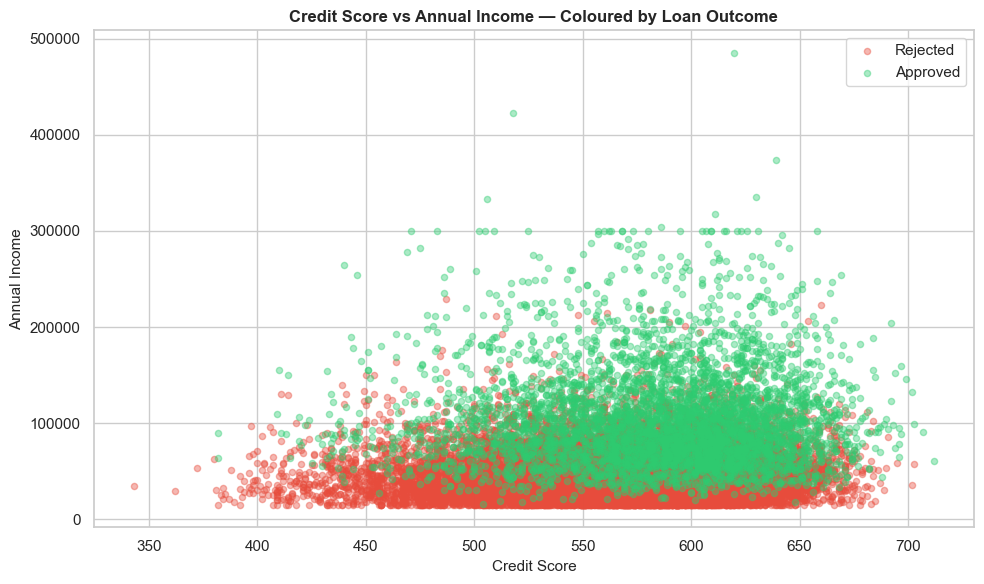

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
for outcome, color, label in [(0, '#e74c3c', 'Rejected'),
                               (1, '#2ecc71', 'Approved')]:
    subset = df_pre_encode[df_pre_encode['LoanApproved'] == outcome]
    ax.scatter(subset['CreditScore'], subset['AnnualIncome'],
               c=color, label=label, alpha=0.4, s=20)

ax.set_xlabel('Credit Score', fontsize=11)
ax.set_ylabel('Annual Income', fontsize=11)
ax.set_title('Credit Score vs Annual Income — Coloured by Loan Outcome',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig('reports/eda/credit_vs_income_scatter.png', bbox_inches='tight')
plt.show()

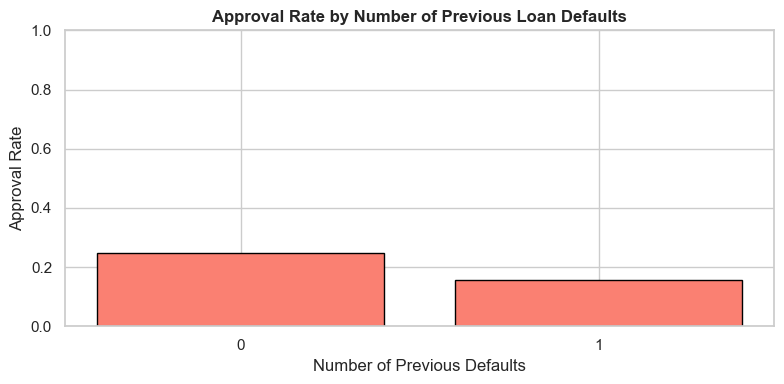

In [30]:
if 'PreviousLoanDefaults' in df_pre_encode.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    default_rate = (df_pre_encode.groupby('PreviousLoanDefaults')
                    ['LoanApproved'].mean())
    ax.bar(default_rate.index.astype(str), default_rate.values,
           color='salmon', edgecolor='black')
    ax.set_title('Approval Rate by Number of Previous Loan Defaults',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Previous Defaults')
    ax.set_ylabel('Approval Rate')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    # plt.savefig('reports/eda/approval_by_defaults.png', bbox_inches='tight')
    plt.show()

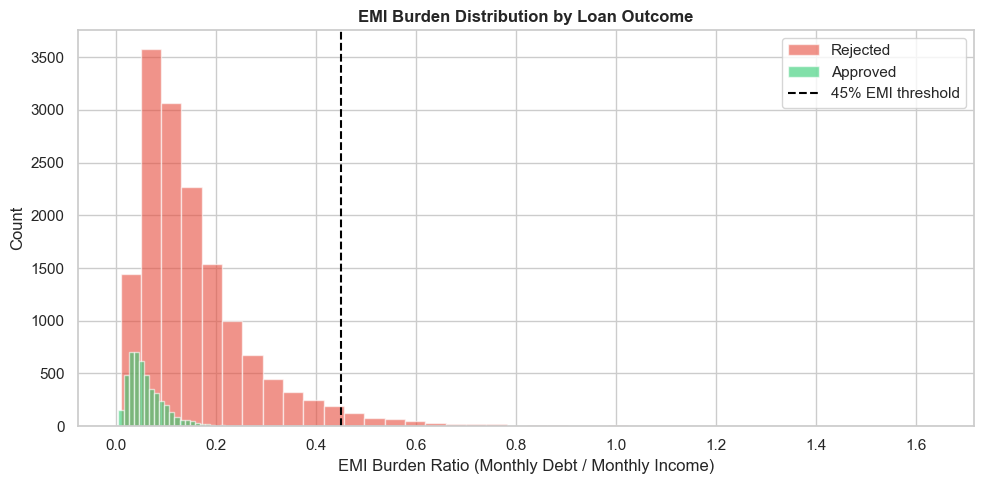

Applicants with EMI burden > 45%: 474
Default rate among them: 100.0%


In [32]:
if 'EMIBurdenRatio' in df_pre_encode.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for outcome, color, label in [(0, '#e74c3c', 'Rejected'), (1, '#2ecc71', 'Approved')]:
        subset = df_pre_encode[df_pre_encode['LoanApproved'] == outcome]
        ax.hist(subset['EMIBurdenRatio'], bins=40, alpha=0.6,
                color=color, label=label, edgecolor='white')
    ax.axvline(x=0.45, color='black', linestyle='--', linewidth=1.5,
               label='45% EMI threshold')
    ax.set_xlabel('EMI Burden Ratio (Monthly Debt / Monthly Income)')
    ax.set_ylabel('Count')
    ax.set_title('EMI Burden Distribution by Loan Outcome', fontsize=12, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    # plt.savefig('reports/eda/emi_burden_distribution.png', bbox_inches='tight')
    plt.show()

    above_threshold = df_pre_encode[df_pre_encode['EMIBurdenRatio'] > 0.45]
    print(f'Applicants with EMI burden > 45%: {len(above_threshold)}')
    print(f'Default rate among them: {(above_threshold["LoanApproved"] == 0).mean():.1%}')

In [ ]:
feature_list = list(X_train_scaled.columns)

features_content = f'''# features.py — FairCredit 2.0
# Auto-generated by Person 1. Do not edit manually.

FEATURE_NAMES = {repr(feature_list)}

TARGET = 'LoanApproved'

PROTECTED_ATTRS = {repr(PROTECTED_ATTRS)}

ENGINEERED_FEATURES = [
    'MissedPaymentFlag',    # 1 if PreviousLoanDefaults > 0
    'HighUtilizationFlag',  # 1 if CreditCardUtilizationRate > 0.75
    'SavingsToLoanRatio',   # SavingsAccountBalance / LoanAmount
    'EMIBurdenRatio',       # MonthlyDebt / MonthlyIncome (cohort analysis)
]

FEATURE_DESCRIPTIONS = {{
    'CreditScore':              'Credit score (higher = more creditworthy)',
    'AnnualIncome':             'Annual income of the applicant',
    'MonthlyIncome':            'Monthly income',
    'LoanAmount':               'Loan amount requested',
    'LoanDuration':             'Loan duration in months',
    'DebtToIncomeRatio':        'Total debt as a fraction of annual income',
    'CreditCardUtilizationRate':'Fraction of credit card limit currently used',
    'PreviousLoanDefaults':     'Number of previous loan defaults',
    'MissedPaymentFlag':        '1 if applicant has any previous loan default',
    'HighUtilizationFlag':      '1 if credit utilization exceeds 75%',
    'SavingsToLoanRatio':       'Savings buffer relative to loan size',
    'EMIBurdenRatio':           'Monthly debt obligations as fraction of monthly income',
    'TotalDebt':                'Total outstanding debt',
    'TotalAssets':              'Total assets owned by applicant',
    'NetWorth':                 'Net worth (Assets minus Liabilities)',
    'JobTenure':                'Years at current job',
    'PaymentHistory':           'Historical payment performance score',
    'LengthOfCreditHistory':    'How long the applicant has had credit accounts',
    'BankruptcyHistory':        'Whether the applicant has declared bankruptcy',
    'NumberOfDependents':       'Number of financial dependents',
    'Experience':               'Total work experience in years',
    'BaselineInterestRate':     'Market baseline interest rate at application time',
    'MonthlyDebt':              'Monthly debt repayment obligations',
    'MonthlyExpenses':          'Total monthly expenses',
    'UtilityBills':             'Monthly utility bill amount',
}}
'''

with open('src/features.py', 'w') as f:
    f.write(features_content)

print('Saved: src/features.py')
print(f'Total model features: {len(feature_list)}')

In [ ]:
import subprocess
result = subprocess.run(
    'pip freeze | grep -E "pandas|numpy|scikit.learn|xgboost|shap|fairlearn|matplotlib|seaborn|streamlit|joblib"',
    shell=True, capture_output=True, text=True
)
with open('requirements.txt', 'w') as f:
    f.write(result.stdout)
print('Saved: requirements.txt')
print(result.stdout)

In [ ]:
handoff_files = {
    'data/processed/X_train.csv':           'Person 2 & 3 — model training features',
    'data/processed/X_test.csv':            'Person 2 & 3 — model evaluation features',
    'data/processed/y_train.csv':           'Person 2 & 3 — training labels',
    'data/processed/y_test.csv':            'Person 2 & 3 — test labels',
    'data/processed/sensitive_train.csv':   'Person 3 — fairness analysis (train)',
    'data/processed/sensitive_test.csv':    'Person 3 — fairness analysis (test)',
    'data/processed/loan_cleaned.csv':      'Reference — cleaned full dataset',
    'data/processed/loan_pre_encode.csv':   'Person 3 & 4 — pre-encoded data with EMIBurdenRatio',
    'models/scaler.pkl':                    'Person 4 — preprocessing new inputs',
    'protected_attrs.txt':                  'Person 3 — which columns to check for bias',
    'src/features.py':                      'All — feature names & descriptions',
    'requirements.txt':                     'All — install dependencies',
    'reports/eda/class_distribution.png':   'Person 4 — dashboard',
    'reports/eda/correlation_heatmap.png':  'Person 3 & 4 — analysis',
    'reports/eda/feature_distributions.png':'Person 4 — dashboard',
    'reports/eda/emi_burden_distribution.png': 'Person 3 — cohort intelligence',
}

print('=' * 60)
print('FAIRCREDIT 2.0 — PERSON 1 HANDOFF CHECKLIST')
print('=' * 60)

all_ok = True
for filepath, desc in handoff_files.items():
    exists = os.path.exists(filepath)
    status = 'OK' if exists else 'MISSING'
    if not exists:
        all_ok = False
    print(f'[{status}]  {filepath}')
    print(f'         -> {desc}')

print('=' * 60)
if all_ok:
    print('ALL FILES READY')
else:
    print('Some files missing. Re-run the relevant cells above.')

In [ ]:
print('=' * 60)
print('HANDOFF NOTES FOR PERSON 2 (MODEL) & PERSON 3 (FAIRNESS)')
print('=' * 60)
print(f'Total rows (after cleaning):  {len(df)}')
print(f'Training rows:                {len(X_train_scaled)}')
print(f'Test rows:                    {len(X_test_scaled)}')
print(f'Number of model features:     {len(feature_list)}')
print(f'Target column:                LoanApproved  (1=Approved, 0=Rejected)')
print(f'Class balance:                {df["LoanApproved"].value_counts().to_dict()}')
print(f'Age range confirmed:          22 to 64')
print(f'Missing values:               None')
print(f'Scaling:                      StandardScaler (fit on train only)')
print(f'Protected attributes:         {PROTECTED_ATTRS}')
print()
print('DROPPED COLUMNS:')
print('  RiskScore        — target leakage')
print('  ApplicationDate  — date string with corrupted future values')
print()
print('ENGINEERED FEATURES ADDED:')
print('  MissedPaymentFlag    (1 if PreviousLoanDefaults > 0)')
print('  HighUtilizationFlag  (1 if CreditCardUtilizationRate > 0.75)')
print('  SavingsToLoanRatio   (SavingsAccountBalance / LoanAmount)')
print('  EMIBurdenRatio       (MonthlyDebt / MonthlyIncome)')
print()
print('NOTE FOR PERSON 2:')
print('  XGBoost is the primary model.')
print('  Use: use_label_encoder=False, eval_metric="logloss"')
print('  Check class balance above — use scale_pos_weight if imbalanced.')
print()
print('NOTE FOR PERSON 3:')
print('  sensitive_train/test.csv rows align exactly with X_train/test.csv rows.')
print('  EMIBurdenRatio is in loan_pre_encode.csv — use for cohort intelligence.')
print('  Group approval rate charts are in reports/eda/.')
print('=' * 60)